# **A. PREPROCESSING DATA**

# **TAHAP 1: INSTALASI DAN IMPORT LIBRARY**

In [ ]:
# 1. Instalasi library
!pip install transformers tqdm datasets openpyxl

import pandas as pd
import numpy as np
import re
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

# Pengaturan tampilan agar rapi
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', 10)

# **TAHAP 2: DATA DISCOVERY**

In [ ]:
# 1. Load Data Raw Asian Airlines
pd.set_option('display.max_colwidth', None)

df_raw = pd.read_excel('dataset_asian_airlines.xlsx')

print("--- [TABEL 1: IDENTIFIKASI VARIABEL ASLI - ASIAN AIRLINES] ---")

discovery_data = {
    'Sumber Data': ['Skytrax (Asian Airlines)'],
    'Nama File': ['dataset_asian_airlines.xlsx'],
    'Variabel Asli (Columns)': [ [df_raw.columns.tolist()] ],
    'Variabel yang Digunakan': [ ['Desc', 'Rating'] ]
}

display(pd.DataFrame(discovery_data))

--- [TABEL 1: IDENTIFIKASI VARIABEL ASLI - ASIAN AIRLINES] ---


,Sumber Data,Nama File,Variabel Asli (Columns),Variabel yang Digunakan
0,Skytrax (Asian Airlines),dataset_asian_airlines.xlsx,"[[web-scraper-order, web-scraper-start-url, Rating, Title, Desc, Aircraft, Type_travel, Seat_Type, Route, Date_Flown, Recomen, seat, cabin, fnb, inflight, ground, wifi, value, sentiment]]","[Desc, Rating]"


In [ ]:
pd.set_option('display.max_colwidth', 20)

display(pd.DataFrame(discovery_data))

# 2. Preview Data Asli dengan Titik-Titik di Tengah
print("\n--- [PRATINJAU DATA ASLI - ASIAN AIRLINES] ---")

# Menampilkan jumlah baris dan kolom yang sebenarnya
print(f"Jumlah keseluruhan data : {len(df_raw)} baris")
print(f"Jumlah kolom asli       : {len(df_raw.columns)} kolom")
print("-" * 45)

df_dots = pd.DataFrame([['...'] * len(df_raw.columns)], columns=df_raw.columns, index=['...'])

preview_raw = pd.concat([df_raw.head(5), df_dots, df_raw.tail(5)])

display(preview_raw)

,Sumber Data,Nama File,Variabel Asli (Columns),Variabel yang Digunakan
0,Skytrax (Asian A...,dataset_asian_ai...,[[web-scraper-or...,"[Desc, Rating]"



--- [PRATINJAU DATA ASLI - ASIAN AIRLINES] ---
Jumlah keseluruhan data : 2999 baris
Jumlah kolom asli       : 19 kolom
---------------------------------------------


,web-scraper-order,web-scraper-start-url,Rating,Title,Desc,Aircraft,Type_travel,Seat_Type,Route,Date_Flown,Recomen,seat,cabin,fnb,inflight,ground,wifi,value,sentiment
0,1760272446-8,https://www.airl...,1/10,"""really did not ...",I couldn't store...,NaN,Family Leisure,Economy Class,Manila to Manche...,August 2015,no,1.0,2.0,2.0,NaN,3.0,NaN,4.0,0
1,1760272482-15,https://www.airl...,1/10,"""I will not use ...",We bought our Ca...,NaN,Couple Leisure,Economy Class,Toronto to Hong ...,September 2015,no,NaN,1.0,NaN,NaN,1.0,NaN,1.0,0
2,1760272586-43,https://www.airl...,1/10,"""rejecting to pa...",5 months ago I b...,NaN,Family Leisure,Economy Class,SYD to KTM via HKG,November 2015,no,3.0,3.0,NaN,NaN,1.0,NaN,1.0,0
3,1760272654-65,https://www.airl...,1/10,"""I cannot recomm...",Manila to London...,NaN,Solo Leisure,Economy Class,MNL to LHR via HKG,December 2015,no,1.0,3.0,2.0,3.0,1.0,NaN,1.0,0
4,1760272683-78,https://www.airl...,1/10,"""never use again""",Manchester to De...,Boeing 777,Couple Leisure,Economy Class,MAN to DPS via HKG,October 2015,no,1.0,1.0,NaN,NaN,1.0,NaN,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2994,1760279121-917,https://www.airl...,9/10,"""the best onboar...",Not Verified | ...,A330-300,Solo Leisure,Economy Class,Istanbul to Tash...,October 2024,yes,5.0,5.0,5.0,5.0,5.0,4.0,5.0,2
2995,1760279149-926,https://www.airl...,9/10,"""excellent busin...",✅ Trip Verified ...,A330-300,Solo Leisure,Business Class,Istanbul to Bangkok,February 2025,yes,4.0,5.0,5.0,NaN,5.0,4.0,5.0,2
2996,1760279227-944,https://www.airl...,9/10,"""very friendly a...",✅ Trip Verified ...,A321 neo,Solo Leisure,Business Class,Manchester to Is...,May 2025,yes,4.0,5.0,4.0,NaN,4.0,4.0,4.0,2
2997,1760279255-958,https://www.airl...,9/10,"""Crew service wa...",✅ Trip Verified ...,A321ceo / A350,Couple Leisure,Business Class,Zagreb to Cape T...,May 2025,yes,5.0,5.0,5.0,NaN,3.0,NaN,5.0,2


# **TAHAP 3: INITIAL CLEANING & PENYELARASAN**

In [ ]:
# --- 1. PENYELARASAN DATA (SELEKSI VARIABEL) ---
pd.set_option('display.max_colwidth', 100)

df_merged = pd.DataFrame()
df_merged['text_original'] = df_raw['Desc'].astype(str)
df_merged['rating_raw'] = df_raw['Rating']

# Menampilkan 15 contoh data awal
print("--- [PRATINJAU 1: HASIL PENYELARASAN DATA (15 SAMPEL)] ---")
display(df_merged.head(15))

--- [PRATINJAU 1: HASIL PENYELARASAN DATA (15 SAMPEL)] ---


,text_original,rating_raw
0,I couldn't store my stuff in front of my seat on this Cathay Pacific Airways flight. I'm quite s...,1/10
1,We bought our Cathay Pacific Airways tickets 8 months ago to travel in November from Toronto to ...,1/10
2,5 months ago I booked air tickets to fly in January 2016 with Cathay from Sydney to Kathmandu vi...,1/10
3,Manila to London via Hong Kong. Terrible experience. Flown this route with Cathay 3 times this y...,1/10
4,Manchester to Denpasar via Hong Kong. First time I travelled with Cathay Pacific and it'll be th...,1/10
...,...,...
10,Hong Kong to Rome with Cathay Pacific. My family of 6 Traveled on CX293. Having already had a po...,1/10
11,✅ Verified Review | Cebu to Zürich via Hong Kong with Cathay Pacific. Normally I don't write a ...,1/10
12,✅ Verified Review | I had booked my tickets from Hyderabad to Melbourne via Hong Kong for our f...,1/10
13,✅ Verified Review | Absolutely horrible except for inflight service. The Cathay agents at SFO a...,1/10


In [ ]:
# --- 2. PENANGANAN MISSING VALUES ---
# Menghitung data kosong
missing_count = df_merged['text_original'].isnull().sum()

# Eksekusi penghapusan
df_merged.dropna(subset=['text_original'], inplace=True)

print("\n--- [LAPORAN 1: PENANGANAN MISSING VALUES] ---")
laporan_missing = pd.DataFrame({
    'Pemeriksaan': ['Baris Kosong (Null/NaN)'],
    'Jumlah': [missing_count],
    'Tindakan': ['Dihapus (Dropna)']
})
display(laporan_missing)


--- [LAPORAN 1: PENANGANAN MISSING VALUES] ---


,Pemeriksaan,Jumlah,Tindakan
0,Baris Kosong (Null/NaN),0,Dihapus (Dropna)


In [ ]:
# --- 3. PENANGANAN DATA DUPLIKAT ---
# Menghitung data yang duplikat berdasarkan isi ulasan
duplicate_count = df_merged.duplicated(subset=['text_original']).sum()

# Eksekusi penghapusan duplikat
df_merged.drop_duplicates(subset=['text_original'], keep='first', inplace=True)

print("\n--- [LAPORAN 2: PENANGANAN DATA DUPLIKAT] ---")
laporan_duplikat = pd.DataFrame({
    'Pemeriksaan': ['Data Terduplikasi'],
    'Jumlah': [duplicate_count],
    'Tindakan': ['Dihapus (Drop Duplicates)']
})
display(laporan_duplikat)


--- [LAPORAN 2: PENANGANAN DATA DUPLIKAT] ---


,Pemeriksaan,Jumlah,Tindakan
0,Data Terduplikasi,0,Dihapus (Drop Duplicates)


In [ ]:
# --- 4. PRATINJAU AKHIR SETELAH PEMBERSIHAN ---
print("\n--- [PRATINJAU DATA BERSIH: FINAL INITIAL CLEANING] ---")
print(f"Total data setelah pembersihan : {len(df_merged)} baris")
print("-" * 55)

# Preview Hasil
df_dots_final = pd.DataFrame([['...'] * len(df_merged.columns)],
                             columns=df_merged.columns,
                             index=['...'])

preview_final = pd.concat([df_merged.head(5), df_dots_final, df_merged.tail(5)])

display(preview_final)


--- [PRATINJAU DATA BERSIH: FINAL INITIAL CLEANING] ---
Total data setelah pembersihan : 2999 baris
-------------------------------------------------------


,text_original,rating_raw
0,I couldn't store my stuff in front of my seat on this Cathay Pacific Airways flight. I'm quite s...,1/10
1,We bought our Cathay Pacific Airways tickets 8 months ago to travel in November from Toronto to ...,1/10
2,5 months ago I booked air tickets to fly in January 2016 with Cathay from Sydney to Kathmandu vi...,1/10
3,Manila to London via Hong Kong. Terrible experience. Flown this route with Cathay 3 times this y...,1/10
4,Manchester to Denpasar via Hong Kong. First time I travelled with Cathay Pacific and it'll be th...,1/10
...,...,...
2994,Not Verified | Simply the best onboard meal of all airlines I have travelled. I began to fly wi...,9/10
2995,✅ Trip Verified | I Flew on flight TK 68 on the 26th February from Istanbul to Bangkok which w...,9/10
2996,✅ Trip Verified | I Flew on flight TK 1996 on the 8th May from Manchester to Istanbul in busin...,9/10
2997,✅ Trip Verified | The check-in and boarding processes in Zagreb were cumbersome though the cre...,9/10


# **TAHAP 4: TEXT PREPROCESSING**

In [ ]:
# --- 1. CLEANING (Hapus Tag Skytrax, URL, Simbol, dan Angka) ---
def cleaning(text):
    text = re.sub(r'✅ Trip Verified |\|', '', text) # Hapus tag verified
    text = re.sub(r'Not Verified |\|', '', text)    # Hapus tag not verified
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text) # Hapus URL/Link
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)            # Hapus simbol & angka
    return re.sub(r'\s+', ' ', text).strip() # Hapus spasi berlebih

# Eksekusi Cleaning
df_merged['Hasil_Cleaning'] = df_merged['text_original'].apply(cleaning)

print("--- [PREVIEW 1: TAHAP CLEANING (PEMBERSIHAN ELEMEN NON-TEKS)] ---")
display(df_merged[['text_original', 'Hasil_Cleaning']].head(10))

--- [PREVIEW 1: TAHAP CLEANING (PEMBERSIHAN ELEMEN NON-TEKS)] ---


,text_original,Hasil_Cleaning
0,I couldn't store my stuff in front of my seat on this Cathay Pacific Airways flight. I'm quite s...,I couldn t store my stuff in front of my seat on this Cathay Pacific Airways flight I m quite sh...
1,We bought our Cathay Pacific Airways tickets 8 months ago to travel in November from Toronto to ...,We bought our Cathay Pacific Airways tickets months ago to travel in November from Toronto to Ho...
2,5 months ago I booked air tickets to fly in January 2016 with Cathay from Sydney to Kathmandu vi...,months ago I booked air tickets to fly in January with Cathay from Sydney to Kathmandu via Hong ...
3,Manila to London via Hong Kong. Terrible experience. Flown this route with Cathay 3 times this y...,Manila to London via Hong Kong Terrible experience Flown this route with Cathay times this year ...
4,Manchester to Denpasar via Hong Kong. First time I travelled with Cathay Pacific and it'll be th...,Manchester to Denpasar via Hong Kong First time I travelled with Cathay Pacific and it ll be the...
5,My wife had broke her ankle he day before traveling back from the Philippines - 2 short journeys...,My wife had broke her ankle he day before traveling back from the Philippines short journeys to ...
6,I booked Cathay Pacific from Hong Kong to Surabaya on 31st January 2016. The flight was supposed...,I booked Cathay Pacific from Hong Kong to Surabaya on st January The flight was supposed to depa...
7,✅ Verified Review | Flew Cathay Pacific Premium Economy from Sydney to Manila via Hong Kong. Th...,Verified Review Flew Cathay Pacific Premium Economy from Sydney to Manila via Hong Kong They cha...
8,✅ Verified Review | I took the Cathay Pacific flight from Hong Kong to Taipei today and I did t...,Verified Review I took the Cathay Pacific flight from Hong Kong to Taipei today and I did the on...
9,Cathay Pacific (CX252) from Heathrow to Clark Field via Hong Kong. Aircraft landed in HK 1 minut...,Cathay Pacific CX from Heathrow to Clark Field via Hong Kong Aircraft landed in HK minute late a...


In [ ]:
# --- 2. CASE FOLDING (Penyelarasan Huruf Kecil) ---
df_merged['Hasil_Case_Folding'] = df_merged['Hasil_Cleaning'].str.lower()

print("\n--- [PREVIEW 2: TAHAP CASE FOLDING (LOWERCASE)] ---")
display(df_merged[['Hasil_Cleaning', 'Hasil_Case_Folding']].head(10))


--- [PREVIEW 2: TAHAP CASE FOLDING (LOWERCASE)] ---


,Hasil_Cleaning,Hasil_Case_Folding
0,I couldn t store my stuff in front of my seat on this Cathay Pacific Airways flight I m quite sh...,i couldn t store my stuff in front of my seat on this cathay pacific airways flight i m quite sh...
1,We bought our Cathay Pacific Airways tickets months ago to travel in November from Toronto to Ho...,we bought our cathay pacific airways tickets months ago to travel in november from toronto to ho...
2,months ago I booked air tickets to fly in January with Cathay from Sydney to Kathmandu via Hong ...,months ago i booked air tickets to fly in january with cathay from sydney to kathmandu via hong ...
3,Manila to London via Hong Kong Terrible experience Flown this route with Cathay times this year ...,manila to london via hong kong terrible experience flown this route with cathay times this year ...
4,Manchester to Denpasar via Hong Kong First time I travelled with Cathay Pacific and it ll be the...,manchester to denpasar via hong kong first time i travelled with cathay pacific and it ll be the...
5,My wife had broke her ankle he day before traveling back from the Philippines short journeys to ...,my wife had broke her ankle he day before traveling back from the philippines short journeys to ...
6,I booked Cathay Pacific from Hong Kong to Surabaya on st January The flight was supposed to depa...,i booked cathay pacific from hong kong to surabaya on st january the flight was supposed to depa...
7,Verified Review Flew Cathay Pacific Premium Economy from Sydney to Manila via Hong Kong They cha...,verified review flew cathay pacific premium economy from sydney to manila via hong kong they cha...
8,Verified Review I took the Cathay Pacific flight from Hong Kong to Taipei today and I did the on...,verified review i took the cathay pacific flight from hong kong to taipei today and i did the on...
9,Cathay Pacific CX from Heathrow to Clark Field via Hong Kong Aircraft landed in HK minute late a...,cathay pacific cx from heathrow to clark field via hong kong aircraft landed in hk minute late a...


In [ ]:
# --- 3. NORMALIZATION (Perbaikan Kata Singkat & Kontraksi Inggris) ---
norm_dict = {
    # Aviation Specific
    'flt': 'flight', 'flts': 'flights', 'apt': 'airport', 'ife': 'entertainment',
    'cabin crew': 'staff', 'flight crew': 'staff', 'ground crew': 'staff', 'crews': 'crew',
    'inflight': 'in flight', 'onboard': 'on board', 'pax': 'passenger', 'layover': 'stopover',
    'ptv': 'personal television', 'f b': 'food and beverage', 'fnb': 'food and beverage',

    # Airport IATA Codes & Locations
    'sin': 'singapore', 'hkg': 'hong kong', 'lhr': 'london heathrow', 'bkk': 'bangkok',
    'kul': 'kuala lumpur', 'dxb': 'dubai', 'icn': 'seoul', 'nrt': 'tokyo narita',
    'lax': 'los angeles', 'sfo': 'san francisco', 'cdg': 'paris', 'ams': 'amsterdam',

    # English Contractions (Penting untuk pemahaman Negasi oleh Transformer)
    "don t": "do not", "dont": "do not", "didn t": "did not", "didnt": "did not",
    "can t": "cannot", "cant": "cannot", "wasn t": "was not", "wasnt": "was not",
    "it s": "it is", "its": "it is", "i m": "i am", "im": "i am", "i ve": "i have",
    "ive": "i have", "won t": "will not", "wont": "will not", "couldn t": "could not",
    "shouldn t": "should not", "hasn t": "has not", "weren t": "were not", "i d": "i would",

    # Informal & Units
    'u': 'you', 'r': 'are', 'b': 'be', 'n': 'and', 'w': 'with', 'v': 'very',
    'ok': 'good', 'thx': 'thanks', 'tks': 'thanks', 'pls': 'please',
    'hrs': 'hours', 'mins': 'minutes', 'approx': 'approximately', 'yr': 'year',

    # Sentiment-heavy Adjectives
    'flyin': 'flying', 'lookin': 'looking', 'travelled': 'traveled', 'fav': 'favorite',
    'excellent': 'good', 'efficient': 'good', 'terrible': 'bad', 'awful': 'bad',
    'horrible': 'bad', 'expensive': 'high price', 'comfy': 'comfortable'
}

def normalization(text):
    # Menggunakan regex agar hanya mengganti kata yang berdiri sendiri (whole word)
    pattern = re.compile(r'\b(' + '|'.join(re.escape(key) for key in norm_dict.keys()) + r')\b')
    return pattern.sub(lambda x: norm_dict[x.group()], text)

# Eksekusi Normalization
df_merged['Hasil_Normalization'] = df_merged['Hasil_Case_Folding'].apply(normalization)

print("\n--- [PREVIEW 3: TAHAP NORMALISASI (KAMUS EKSTENSIF)] ---")
display(df_merged[['Hasil_Case_Folding', 'Hasil_Normalization']].head(10))


--- [PREVIEW 3: TAHAP NORMALISASI (KAMUS EKSTENSIF)] ---


,Hasil_Case_Folding,Hasil_Normalization
0,i couldn t store my stuff in front of my seat on this cathay pacific airways flight i m quite sh...,i could not store my stuff in front of my seat on this cathay pacific airways flight i am quite ...
1,we bought our cathay pacific airways tickets months ago to travel in november from toronto to ho...,we bought our cathay pacific airways tickets months ago to travel in november from toronto to ho...
2,months ago i booked air tickets to fly in january with cathay from sydney to kathmandu via hong ...,months ago i booked air tickets to fly in january with cathay from sydney to kathmandu via hong ...
3,manila to london via hong kong terrible experience flown this route with cathay times this year ...,manila to london via hong kong bad experience flown this route with cathay times this year and t...
4,manchester to denpasar via hong kong first time i travelled with cathay pacific and it ll be the...,manchester to denpasar via hong kong first time i traveled with cathay pacific and it ll be the ...
5,my wife had broke her ankle he day before traveling back from the philippines short journeys to ...,my wife had broke her ankle he day before traveling back from the philippines short journeys to ...
6,i booked cathay pacific from hong kong to surabaya on st january the flight was supposed to depa...,i booked cathay pacific from hong kong to surabaya on st january the flight was supposed to depa...
7,verified review flew cathay pacific premium economy from sydney to manila via hong kong they cha...,verified review flew cathay pacific premium economy from sydney to manila via hong kong they cha...
8,verified review i took the cathay pacific flight from hong kong to taipei today and i did the on...,verified review i took the cathay pacific flight from hong kong to taipei today and i did the on...
9,cathay pacific cx from heathrow to clark field via hong kong aircraft landed in hk minute late a...,cathay pacific cx from heathrow to clark field via hong kong aircraft landed in hk minute late a...


In [ ]:
# --- 4. TOKENIZATION (Pemecahan Kalimat Menjadi Kata) ---
df_merged['Hasil_Tokenizing'] = df_merged['Hasil_Normalization'].apply(lambda x: x.split())

print("\n--- [PREVIEW 4: TAHAP TOKENIZING (SPLIT WORDS)] ---")
display(df_merged[['Hasil_Normalization', 'Hasil_Tokenizing']].head(10))


--- [PREVIEW 4: TAHAP TOKENIZING (SPLIT WORDS)] ---


,Hasil_Normalization,Hasil_Tokenizing
0,i could not store my stuff in front of my seat on this cathay pacific airways flight i am quite ...,"[i, could, not, store, my, stuff, in, front, of, my, seat, on, this, cathay, pacific, airways, f..."
1,we bought our cathay pacific airways tickets months ago to travel in november from toronto to ho...,"[we, bought, our, cathay, pacific, airways, tickets, months, ago, to, travel, in, november, from..."
2,months ago i booked air tickets to fly in january with cathay from sydney to kathmandu via hong ...,"[months, ago, i, booked, air, tickets, to, fly, in, january, with, cathay, from, sydney, to, kat..."
3,manila to london via hong kong bad experience flown this route with cathay times this year and t...,"[manila, to, london, via, hong, kong, bad, experience, flown, this, route, with, cathay, times, ..."
4,manchester to denpasar via hong kong first time i traveled with cathay pacific and it ll be the ...,"[manchester, to, denpasar, via, hong, kong, first, time, i, traveled, with, cathay, pacific, and..."
5,my wife had broke her ankle he day before traveling back from the philippines short journeys to ...,"[my, wife, had, broke, her, ankle, he, day, before, traveling, back, from, the, philippines, sho..."
6,i booked cathay pacific from hong kong to surabaya on st january the flight was supposed to depa...,"[i, booked, cathay, pacific, from, hong, kong, to, surabaya, on, st, january, the, flight, was, ..."
7,verified review flew cathay pacific premium economy from sydney to manila via hong kong they cha...,"[verified, review, flew, cathay, pacific, premium, economy, from, sydney, to, manila, via, hong,..."
8,verified review i took the cathay pacific flight from hong kong to taipei today and i did the on...,"[verified, review, i, took, the, cathay, pacific, flight, from, hong, kong, to, taipei, today, a..."
9,cathay pacific cx from heathrow to clark field via hong kong aircraft landed in hk minute late a...,"[cathay, pacific, cx, from, heathrow, to, clark, field, via, hong, kong, aircraft, landed, in, h..."


In [ ]:
# --- RINGKASAN FINAL PREPROCESSING ---
print("\n--- [TABEL RINGKASAN: PERUBAHAN TEKS DARI AWAL HINGGA AKHIR] ---")
display(df_merged[['text_original', 'Hasil_Cleaning', 'Hasil_Case_Folding', 'Hasil_Normalization', 'Hasil_Tokenizing']].head(10))


--- [TABEL RINGKASAN: PERUBAHAN TEKS DARI AWAL HINGGA AKHIR] ---


,text_original,Hasil_Cleaning,Hasil_Case_Folding,Hasil_Normalization,Hasil_Tokenizing
0,I couldn't store my stuff in front of my seat on this Cathay Pacific Airways flight. I'm quite s...,I couldn t store my stuff in front of my seat on this Cathay Pacific Airways flight I m quite sh...,i couldn t store my stuff in front of my seat on this cathay pacific airways flight i m quite sh...,i could not store my stuff in front of my seat on this cathay pacific airways flight i am quite ...,"[i, could, not, store, my, stuff, in, front, of, my, seat, on, this, cathay, pacific, airways, f..."
1,We bought our Cathay Pacific Airways tickets 8 months ago to travel in November from Toronto to ...,We bought our Cathay Pacific Airways tickets months ago to travel in November from Toronto to Ho...,we bought our cathay pacific airways tickets months ago to travel in november from toronto to ho...,we bought our cathay pacific airways tickets months ago to travel in november from toronto to ho...,"[we, bought, our, cathay, pacific, airways, tickets, months, ago, to, travel, in, november, from..."
2,5 months ago I booked air tickets to fly in January 2016 with Cathay from Sydney to Kathmandu vi...,months ago I booked air tickets to fly in January with Cathay from Sydney to Kathmandu via Hong ...,months ago i booked air tickets to fly in january with cathay from sydney to kathmandu via hong ...,months ago i booked air tickets to fly in january with cathay from sydney to kathmandu via hong ...,"[months, ago, i, booked, air, tickets, to, fly, in, january, with, cathay, from, sydney, to, kat..."
3,Manila to London via Hong Kong. Terrible experience. Flown this route with Cathay 3 times this y...,Manila to London via Hong Kong Terrible experience Flown this route with Cathay times this year ...,manila to london via hong kong terrible experience flown this route with cathay times this year ...,manila to london via hong kong bad experience flown this route with cathay times this year and t...,"[manila, to, london, via, hong, kong, bad, experience, flown, this, route, with, cathay, times, ..."
4,Manchester to Denpasar via Hong Kong. First time I travelled with Cathay Pacific and it'll be th...,Manchester to Denpasar via Hong Kong First time I travelled with Cathay Pacific and it ll be the...,manchester to denpasar via hong kong first time i travelled with cathay pacific and it ll be the...,manchester to denpasar via hong kong first time i traveled with cathay pacific and it ll be the ...,"[manchester, to, denpasar, via, hong, kong, first, time, i, traveled, with, cathay, pacific, and..."
5,My wife had broke her ankle he day before traveling back from the Philippines - 2 short journeys...,My wife had broke her ankle he day before traveling back from the Philippines short journeys to ...,my wife had broke her ankle he day before traveling back from the philippines short journeys to ...,my wife had broke her ankle he day before traveling back from the philippines short journeys to ...,"[my, wife, had, broke, her, ankle, he, day, before, traveling, back, from, the, philippines, sho..."
6,I booked Cathay Pacific from Hong Kong to Surabaya on 31st January 2016. The flight was supposed...,I booked Cathay Pacific from Hong Kong to Surabaya on st January The flight was supposed to depa...,i booked cathay pacific from hong kong to surabaya on st january the flight was supposed to depa...,i booked cathay pacific from hong kong to surabaya on st january the flight was supposed to depa...,"[i, booked, cathay, pacific, from, hong, kong, to, surabaya, on, st, january, the, flight, was, ..."
7,✅ Verified Review | Flew Cathay Pacific Premium Economy from Sydney to Manila via Hong Kong. Th...,Verified Review Flew Cathay Pacific Premium Economy from Sydney to Manila via Hong Kong They cha...,verified review flew cathay pacific premium economy from sydney to manila via hong kong they cha...,verified review flew cathay pacific premium economy from sydney to manila via hong ko

# **TAHAP 5: LABELLING DATA (RATING-BASED)**

In [ ]:
def rating_labelling(val):
    try:
        # Extract pure numeric score from 'X/10' format
        if isinstance(val, str) and '/' in val:
            score = int(val.split('/')[0])
        else:
            score = int(val)

        # Determine Ordinal Labels (0: Negative, 1: Neutral, 2: Positive)
        if score <= 4:
            return 'negative', 0
        elif score <= 6:
            return 'neutral', 1
        else:
            return 'positive', 2
    except:
        # Fallback to neutral in case of missing or corrupted data
        return 'neutral', 1

# Execute Labeling Process
results = df_merged['rating_raw'].apply(rating_labelling)
df_merged[['sentiment_name', 'label']] = pd.DataFrame(results.tolist(), index=df_merged.index)

print("--- [LABELING VERIFICATION: 1-10 RATING REPRESENTATION] ---")

pd.set_option('display.max_rows', 20)
pd.set_option('display.max_colwidth', 60)

# Retrieve samples for each rating value (1-10) for verification
# We take one unique example for each rating score available in the dataset
verification_samples = df_merged.drop_duplicates(subset=['rating_raw']).sort_values(by='label')

display(verification_samples[['Hasil_Normalization', 'rating_raw', 'sentiment_name', 'label']])

# Display distribution statistics
print("\n--- [LABELING STATISTICS SUMMARY] ---")
print(df_merged['sentiment_name'].value_counts())

--- [LABELING VERIFICATION: 1-10 RATING REPRESENTATION] ---


,Hasil_Normalization,rating_raw,sentiment_name,label
0,i could not store my stuff in front of my seat on this c...,1/10,negative,0
306,cathay pacific airways was a very disappointing airline ...,2/10,negative,0
371,i have been a gold member with cathay pacific airways fo...,3/10,negative,0
432,new york to hong kong with cathay pacific airways in pre...,4/10,negative,0
559,vancouver to perth via hong kong on cathay pacific full ...,6/10,neutral,1
485,sydney to hong kong with cathay pacific was an okay flig...,5/10,neutral,1
131,i am an international student studying in canada and i f...,10/10,positive,2
602,hong kong tpe hong kong i believe my flight was connecti...,7/10,positive,2
687,organisation of ground and in flight staff was good a co...,8/10,positive,2
825,very good flight with cathay pacific airways from london...,9/10,positive,2



--- [LABELING STATISTICS SUMMARY] ---
sentiment_name
negative    1384
positive    1318
neutral      297
Name: count, dtype: int64


In [ ]:
# --- 7. SIMPAN KE EXCEL ---
nama_file = "dataset_asian_airlines_preprocessing.xlsx"
df_merged.to_excel(nama_file, index=False)

print(f"\n[INFO] File berhasil disimpan sebagai: {nama_file}")


[INFO] File berhasil disimpan sebagai: dataset_asian_airlines_preprocessing.xlsx


/tmp/ipykernel_3870/1713309501.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=['#e74c3c', '#2ecc71', '#f1c40f'])


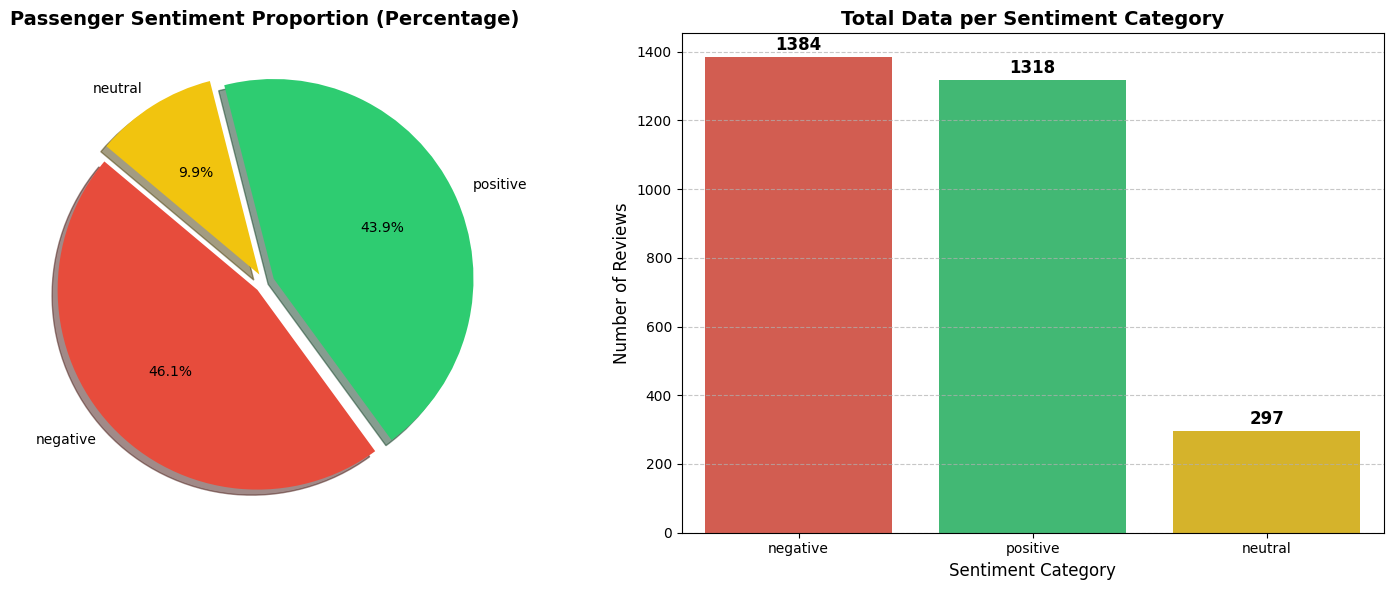

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- [SENTIMENT DISTRIBUTION VISUALIZATION] ---

# 1. Prepare data for plotting
sentiment_counts = df_merged['sentiment_name'].value_counts()
# Define aesthetic properties
explode = (0.05, 0.05, 0.05) # Slightly separate the pie slices for better clarity

# 2. Initialize visualization canvas (1 row, 2 columns)
plt.figure(figsize=(15, 6))

# --- SUBPLOT 1: PIE CHART (PROPORTION) ---
plt.subplot(1, 2, 1)
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
        startangle=140, colors=['#e74c3c', '#2ecc71', '#f1c40f'], explode=explode, shadow=True)
plt.title('Passenger Sentiment Proportion (Percentage)', fontsize=14, fontweight='bold')

# --- SUBPLOT 2: BAR CHART (TOTAL COUNTS) ---
plt.subplot(1, 2, 2)
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=['#e74c3c', '#2ecc71', '#f1c40f'])

# Add data labels on top of each bar for better readability
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold', fontsize=12)

plt.title('Total Data per Sentiment Category', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# **TAHAP 6: DATA SPLITTING**

In [ ]:
# Splitting the dataset into 80% Training and 20% Testing sets
df_train, df_test = train_test_split(
    df_merged, test_size=0.2, random_state=42, stratify=df_merged['label']
)

print(f"--- [DATASET SPLIT INFORMATION] ---")
print(f"Total Training Samples (80%): {len(df_train)}")
print(f"Total Testing Samples (20%) : {len(df_test)}")

--- [DATASET SPLIT INFORMATION] ---
Total Training Samples (80%): 2399
Total Testing Samples (20%) : 600


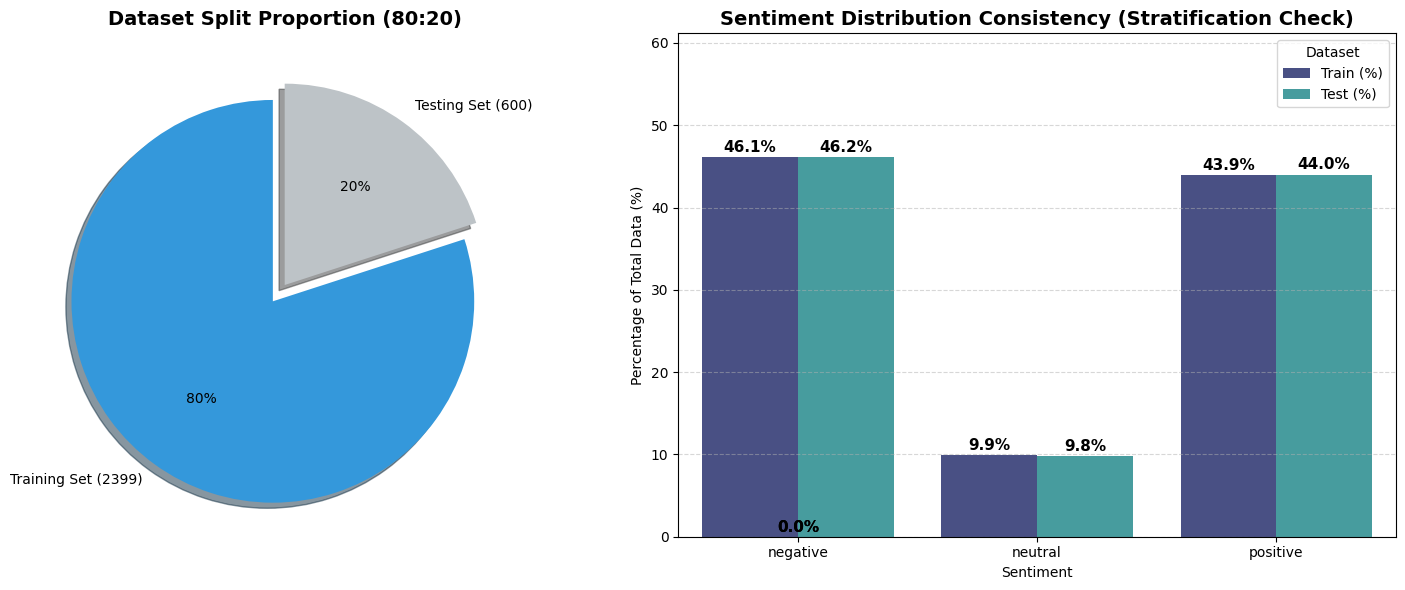

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- [DATASET SPLIT & STRATIFICATION VISUALIZATION] ---

# 1. Prepare data for Train vs Test proportion
split_counts = [len(df_train), len(df_test)]
split_labels = [f'Training Set ({len(df_train)})', f'Testing Set ({len(df_test)})']

# 2. Prepare data for stratification check (sentiment distribution in both sets)
train_dist = df_train['sentiment_name'].value_counts(normalize=True).sort_index() * 100
test_dist = df_test['sentiment_name'].value_counts(normalize=True).sort_index() * 100

df_dist = pd.DataFrame({
    'Sentiment': train_dist.index,
    'Train (%)': train_dist.values,
    'Test (%)': test_dist.values
}).melt(id_vars='Sentiment', var_name='Dataset', value_name='Percentage')

# 3. Create Visualization
plt.figure(figsize=(15, 6))

# --- SUBPLOT 1: PIE CHART (SPLIT PROPORTION) ---
plt.subplot(1, 2, 1)
plt.pie(split_counts, labels=split_labels, autopct='%1.0f%%',
        startangle=90, colors=['#3498db', '#bdc3c7'], explode=(0.1, 0), shadow=True)
plt.title('Dataset Split Proportion (80:20)', fontsize=14, fontweight='bold')

# --- SUBPLOT 2: GROUPED BAR CHART (STRATIFICATION CHECK) ---
plt.subplot(1, 2, 2)
sns.barplot(data=df_dist, x='Sentiment', y='Percentage', hue='Dataset', palette='mako')

# Add percentage labels above bars for clarity
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1f}%',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=11, color='black',
                       xytext=(0, 7), textcoords='offset points', fontweight='bold')

plt.title('Sentiment Distribution Consistency (Stratification Check)', fontsize=14, fontweight='bold')
plt.ylabel('Percentage of Total Data (%)')
plt.ylim(0, max(df_dist['Percentage']) + 15) # Add padding for text labels
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# **B. TRANSFORMER TOKENIZATION LAYER**

In [ ]:
from transformers import AutoTokenizer
import pandas as pd
from tqdm.auto import tqdm

# 1. Configure Pandas to display full column width without truncation
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

# List of architectures to compare
architectures = {
    "BERT": "bert-base-uncased",
    "RoBERTa": "roberta-base",
    "DeBERTa": "microsoft/deberta-base" # Updated to match your stable version choice
}

# Select a single review sample (using the first row as an example)
sample_review = df_train['Hasil_Normalization'].iloc[0]

print(f"--- [STEP B: CROSS-ARCHITECTURE TOKENIZATION VIEW] ---")
print(f"Original Review: {sample_review}\n")

comparison_list = []

for name, path in tqdm(architectures.items(), desc="Processing"):
    tokenizer = AutoTokenizer.from_pretrained(path)

    # Encode the text to get input IDs
    input_ids = tokenizer.encode(sample_review, add_special_tokens=True)

    # Convert IDs back to tokens to visualize special tokens ([CLS]/<s>, etc.)
    full_tokens = tokenizer.convert_ids_to_tokens(input_ids)

    comparison_list.append({
        'Architecture': name,
        'Full Token Sequence': " | ".join(full_tokens), # Using '|' separator for better readability
        'Total Tokens': len(full_tokens)
    })

# Generate and display the comparison table
df_compare = pd.DataFrame(comparison_list)
display(df_compare)

--- [STEP B: CROSS-ARCHITECTURE TOKENIZATION VIEW] ---
Original Review: verified review manila to auckland via hong kong with cathay pacific ground staff and staff were polite and well fed throughout the flight in flight entertainment selection was good and lavatories are clean and stocked wish that baggage allowance is generous like of qantas or pal economy kg



Processing:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

,Architecture,Full Token Sequence,Total Tokens
0,BERT,[CLS] | verified | review | manila | to | auckland | via | hong | kong | with | cat | ##hay | pacific | ground | staff | and | staff | were | polite | and | well | fed | throughout | the | flight | in | flight | entertainment | selection | was | good | and | lava | ##tori | ##es | are | clean | and | stocked | wish | that | baggage | allowance | is | generous | like | of | q | ##anta | ##s | or | pal | economy | kg | [SEP],55
1,RoBERTa,<s> | verified | Ġreview | Ġman | ila | Ġto | Ġa | uckland | Ġvia | Ġh | ong | Ġk | ong | Ġwith | Ġcath | ay | Ġpac | ific | Ġground | Ġstaff | Ġand | Ġstaff | Ġwere | Ġpolite | Ġand | Ġwell | Ġfed | Ġthroughout | Ġthe | Ġflight | Ġin | Ġflight | Ġentertainment | Ġselection | Ġwas | Ġgood | Ġand | Ġlav | atories | Ġare | Ġclean | Ġand | Ġstocked | Ġwish | Ġthat | Ġbaggage | Ġallowance | Ġis | Ġgenerous | Ġlike | Ġof | Ġq | ant | as | Ġor | Ġpal | Ġeconomy | Ġkg | </s>,59
2,DeBERTa,[CLS] | verified | Ġreview | Ġman | ila | Ġto | Ġa | uckland | Ġvia | Ġh | ong | Ġk | ong | Ġwith | Ġcath | ay | Ġpac | ific | Ġground | Ġstaff | Ġand | Ġstaff | Ġwere | Ġpolite | Ġand | Ġwell | Ġfed | Ġthroughout | Ġthe | Ġflight | Ġin | Ġflight | Ġentertainment | Ġselection | Ġwas | Ġgood | Ġand | Ġlav | atories | Ġare | Ġclean | Ġand | Ġstocked | Ġwish | Ġthat | Ġbaggage | Ġallowance | Ġis | Ġgenerous | Ġlike | Ġof | Ġq | ant | as | Ġor | Ġpal | Ġeconomy | Ġkg | [SEP],59


# **C. FINE-TUNE TASK (BERT, ROBERTA, DEBERTA)**

In [ ]:
import torch
import torch.nn as nn
import random
import numpy as np
import os
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import Dataset

# 1. Table Display Configuration (Standard & Clean)
pd.reset_option('display.max_colwidth')
pd.set_option('display.max_colwidth', 50)

# 2. Global Seed Configuration for Result Consistency
def set_seed(seed_value=42):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    print(f"System locked with Seed: {seed_value}")

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. Dataset Class Definition
class AirlineReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        inputs = self.tokenizer(text, truncation=True, padding='max_length', max_length=self.max_len, return_tensors='pt')
        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# 4. Evaluation Metrics Calculation Function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro')
    }

# 5. Aspect Detection Function (Extended Keywords)
def add_aspect_detection(df):
    rules = {
        'Aspect_FNB': ['food', 'meal', 'drink', 'beverage', 'catering', 'delicious', 'breakfast', 'lunch', 'dinner', 'snack'],
        'Aspect_Seat_Cabin': ['seat', 'legroom', 'cabin', 'space', 'comfortable', 'recline', 'pitch', 'cleanliness', 'aisle'],
        'Aspect_Staff_Service': ['staff', 'crew', 'service', 'attendant', 'polite', 'friendly', 'helpful', 'attitude', 'hostess'],
        'Aspect_Ground_Service': ['ground', 'check in', 'boarding', 'lounge', 'airport', 'counter', 'queue', 'gate', 'delay'],
        'Aspect_Wifi_Inflight': ['wifi', 'ife', 'internet', 'entertainment', 'movie', 'screen', 'video', 'music', 'game']
    }
    for aspect, keywords in rules.items():
        df[aspect] = df['Hasil_Normalization'].apply(
            lambda x: 1 if any(word in str(x).lower() for word in keywords) else 0
        )
    return df

# Execute Aspect Detection on the datasets
df_train = add_aspect_detection(df_train.copy())
df_test = add_aspect_detection(df_test.copy())

# Column list for preview display
cols_preview = ['Hasil_Normalization', 'sentiment_name', 'Aspect_FNB', 'Aspect_Seat_Cabin',
                'Aspect_Staff_Service', 'Aspect_Ground_Service', 'Aspect_Wifi_Inflight']

print("Step 1 Complete: Aspect Detection has been configured.")

System locked with Seed: 42
Step 1 Complete: Aspect Detection has been configured.


# **1. FINE-TUNING TASK: BERT MODEL**

In [ ]:
print(f"\n{'='*60}\nSTEP 1: BERT MODEL - SENTIMENT & ASPECT DETECTION\n{'='*60}")

# 1. Load Model & Tokenizer
path_bert = "bert-base-uncased"
tokenizer_bert = AutoTokenizer.from_pretrained(path_bert)
model_bert = AutoModelForSequenceClassification.from_pretrained(path_bert, num_labels=3).to(device)

# 2. Training Configuration
args_bert = TrainingArguments(
    output_dir='./res_bert',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    seed=42,
    data_seed=42,
    report_to="none"
)

# 3. Training Execution
trainer_bert = Trainer(
    model=model_bert,
    args=args_bert,
    train_dataset=AirlineReviewDataset(df_train['Hasil_Normalization'], df_train['label'], tokenizer_bert),
    eval_dataset=AirlineReviewDataset(df_test['Hasil_Normalization'], df_test['label'], tokenizer_bert),
    compute_metrics=compute_metrics
)

print("Training BERT-Base-Uncased...")
trainer_bert.train()

# 4. Generate Predictions (Testing Set)
preds_bert = np.argmax(trainer_bert.predict(
    AirlineReviewDataset(df_test['Hasil_Normalization'], df_test['label'], tokenizer_bert)
).predictions, axis=-1)

df_res_bert = df_test.copy()
df_res_bert['Sentiment_BERT'] = pd.Series(preds_bert, index=df_test.index).map({
    0: 'negative', 1: 'neutral', 2: 'positive'
})

# 5. Model Output Verification
print("\n[VERIFICATION] Prediction distribution across all classes:")
print(df_res_bert['Sentiment_BERT'].value_counts())

print("\n" + "="*60)
print("--- [FINAL OUTPUT: BERT SENTIMENT & ASPECT DETECTION] ---")
print("="*60)

display(df_res_bert[[
    'Hasil_Normalization',
    'sentiment_name',
    'Sentiment_BERT',
    'Aspect_FNB',
    'Aspect_Seat_Cabin',
    'Aspect_Staff_Service',
    'Aspect_Ground_Service',
    'Aspect_Wifi_Inflight'
]].head(15))


STEP 1: BERT MODEL - SENTIMENT & ASPECT DETECTION


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training BERT-Base-Uncased...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


[VERIFICATION] Prediction distribution across all classes:
Sentiment_BERT
negative    290
positive    277
neutral      33
Name: count, dtype: int64

--- [FINAL OUTPUT: BERT SENTIMENT & ASPECT DETECTION] ---


,Hasil_Normalization,sentiment_name,Sentiment_BERT,Aspect_FNB,Aspect_Seat_Cabin,Aspect_Staff_Service,Aspect_Ground_Service,Aspect_Wifi_Inflight
1108,seats that we paid for and confirmed very much...,negative,negative,0,1,1,1,0
232,new york jfk to hong kong i want to sincerely ...,positive,positive,1,1,1,1,0
1573,hnd singapore was pretty poor cabin staff did ...,neutral,positive,1,1,1,1,0
2148,my flight had a connection in istanbul however...,negative,negative,0,0,1,1,0
1534,manchester to houston some hostesses were very...,neutral,neutral,0,1,1,0,0
2941,the airport was a little bit dirty when i step...,positive,positive,1,1,1,1,1
130,paid in full for extra room seats they over bo...,negative,negative,0,1,1,1,0
2052,we are living a nightmare with this company my...,negative,negative,0,0,0,1,0
1918,flew singapore airlines from singapore to bang...,positive,positive,1,1,1,0,1
1849,amsterdam to melbourne via singapore with sing...,positive,positive,1,1,1,0,1


# **2. FINE-TUNING TASK: ROBERTA MODEL**

In [ ]:
print(f"\n{'='*60}\nSTEP 2: RoBERTa MODEL - SENTIMENT & ASPECT DETECTION\n{'='*60}")

# 1. Load Model & Tokenizer
path_rob = "roberta-base"
tokenizer_rob = AutoTokenizer.from_pretrained(path_rob)
model_rob = AutoModelForSequenceClassification.from_pretrained(path_rob, num_labels=3).to(device)

# 2. Training Configuration
args_rob = TrainingArguments(
    output_dir='./res_rob',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    seed=42,
    data_seed=42,
    report_to="none"
)

# 3. Training Execution
trainer_rob = Trainer(
    model=model_rob,
    args=args_rob,
    train_dataset=AirlineReviewDataset(df_train['Hasil_Normalization'], df_train['label'], tokenizer_rob),
    eval_dataset=AirlineReviewDataset(df_test['Hasil_Normalization'], df_test['label'], tokenizer_rob),
    compute_metrics=compute_metrics
)

print("Training RoBERTa-Base...")
trainer_rob.train()

# 4. Generate Predictions (Testing Set)
preds_rob = np.argmax(trainer_rob.predict(
    AirlineReviewDataset(df_test['Hasil_Normalization'], df_test['label'], tokenizer_rob)
).predictions, axis=-1)

df_res_rob = df_test.copy()
df_res_rob['Sentiment_RoBERTa'] = pd.Series(preds_rob, index=df_test.index).map({
    0: 'negative', 1: 'neutral', 2: 'positive'
})

# 5. Model Output Verification
print("\n[VERIFICATION] Prediction distribution across all classes:")
print(df_res_rob['Sentiment_RoBERTa'].value_counts())

print("\n" + "="*60)
print("--- [FINAL OUTPUT: RoBERTa SENTIMENT & ASPECT DETECTION] ---")
print("="*60)

display(df_res_rob[[
    'Hasil_Normalization',
    'sentiment_name',
    'Sentiment_RoBERTa',
    'Aspect_FNB',
    'Aspect_Seat_Cabin',
    'Aspect_Staff_Service',
    'Aspect_Ground_Service',
    'Aspect_Wifi_Inflight'
]].head(15))


STEP 2: RoBERTa MODEL - SENTIMENT & ASPECT DETECTION


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training RoBERTa-Base...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


[VERIFICATION] Prediction distribution across all classes:
Sentiment_RoBERTa
negative    276
positive    269
neutral      55
Name: count, dtype: int64

--- [FINAL OUTPUT: RoBERTa SENTIMENT & ASPECT DETECTION] ---


,Hasil_Normalization,sentiment_name,Sentiment_RoBERTa,Aspect_FNB,Aspect_Seat_Cabin,Aspect_Staff_Service,Aspect_Ground_Service,Aspect_Wifi_Inflight
1108,seats that we paid for and confirmed very much...,negative,negative,0,1,1,1,0
232,new york jfk to hong kong i want to sincerely ...,positive,positive,1,1,1,1,0
1573,hnd singapore was pretty poor cabin staff did ...,neutral,neutral,1,1,1,1,0
2148,my flight had a connection in istanbul however...,negative,negative,0,0,1,1,0
1534,manchester to houston some hostesses were very...,neutral,neutral,0,1,1,0,0
2941,the airport was a little bit dirty when i step...,positive,positive,1,1,1,1,1
130,paid in full for extra room seats they over bo...,negative,negative,0,1,1,1,0
2052,we are living a nightmare with this company my...,negative,negative,0,0,0,1,0
1918,flew singapore airlines from singapore to bang...,positive,positive,1,1,1,0,1
1849,amsterdam to melbourne via singapore with sing...,positive,positive,1,1,1,0,1


# **3. FINE-TUNING TASK: DEBERTA MODEL**

In [ ]:
print(f"\n{'='*60}\nSTEP 3: DeBERTa MODEL - SENTIMENT & ASPECT DETECTION\n{'='*60}")

# 1. Load Model & Tokenizer - Using stable DeBERTa-base (v1)
path_deb = "microsoft/deberta-base"
tokenizer_deb = AutoTokenizer.from_pretrained(path_deb)
model_deb = AutoModelForSequenceClassification.from_pretrained(path_deb, num_labels=3).to(device)

# 2. Training Configuration
args_deb = TrainingArguments(
    output_dir='./res_deb_fixed',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    learning_rate=1e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    seed=42,
    data_seed=42,
    report_to="none"
)

# 3. Training Execution
trainer_deb = Trainer(
    model=model_deb,
    args=args_deb,
    train_dataset=AirlineReviewDataset(df_train['Hasil_Normalization'], df_train['label'], tokenizer_deb),
    eval_dataset=AirlineReviewDataset(df_test['Hasil_Normalization'], df_test['label'], tokenizer_deb),
    compute_metrics=compute_metrics
)

print("Training DeBERTa-Base...")
trainer_deb.train()

# 4. Generate Predictions (Testing Set)
preds_deb = np.argmax(trainer_deb.predict(
    AirlineReviewDataset(df_test['Hasil_Normalization'], df_test['label'], tokenizer_deb)
).predictions, axis=-1)

df_res_deb = df_test.copy()
df_res_deb['Sentiment_DeBERTa'] = pd.Series(preds_deb, index=df_test.index).map({
    0: 'negative', 1: 'neutral', 2: 'positive'
})

# 5. Model Output Verification
print("\n[VERIFICATION] Prediction distribution across all classes:")
print(df_res_deb['Sentiment_DeBERTa'].value_counts())

print("\n" + "="*60)
print("--- [FINAL OUTPUT: DeBERTa SENTIMENT & ASPECT DETECTION] ---")
print("="*60)

display(df_res_deb[[
    'Hasil_Normalization',
    'sentiment_name',
    'Sentiment_DeBERTa',
    'Aspect_FNB',
    'Aspect_Seat_Cabin',
    'Aspect_Staff_Service',
    'Aspect_Ground_Service',
    'Aspect_Wifi_Inflight'
]].head(15))


STEP 3: DeBERTa MODEL - SENTIMENT & ASPECT DETECTION


pytorch_model.bin:   0%|          | 0.00/559M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

DebertaForSequenceClassification LOAD REPORT from: microsoft/deberta-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/559M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye


[VERIFICATION] Prediction distribution across all classes:
Sentiment_DeBERTa
negative    308
positive    264
neutral      28
Name: count, dtype: int64

--- [FINAL OUTPUT: DeBERTa SENTIMENT & ASPECT DETECTION] ---


,Hasil_Normalization,sentiment_name,Sentiment_DeBERTa,Aspect_FNB,Aspect_Seat_Cabin,Aspect_Staff_Service,Aspect_Ground_Service,Aspect_Wifi_Inflight
1108,seats that we paid for and confirmed very much...,negative,negative,0,1,1,1,0
232,new york jfk to hong kong i want to sincerely ...,positive,positive,1,1,1,1,0
1573,hnd singapore was pretty poor cabin staff did ...,neutral,neutral,1,1,1,1,0
2148,my flight had a connection in istanbul however...,negative,negative,0,0,1,1,0
1534,manchester to houston some hostesses were very...,neutral,neutral,0,1,1,0,0
2941,the airport was a little bit dirty when i step...,positive,positive,1,1,1,1,1
130,paid in full for extra room seats they over bo...,negative,negative,0,1,1,1,0
2052,we are living a nightmare with this company my...,negative,negative,0,0,0,1,0
1918,flew singapore airlines from singapore to bang...,positive,positive,1,1,1,0,1
1849,amsterdam to melbourne via singapore with sing...,positive,positive,1,1,1,0,1


# **D. PERFORMANCE EVALUATION**


PERFORMANCE EVALUATION: BERT


Accuracy  : 0.8500
F1-Macro  : 0.6864
AUC Score : 0.9103

--- Detailed Classification Report ---
              precision    recall  f1-score   support

    Negative       0.87      0.91      0.89       277
     Neutral       0.36      0.20      0.26        59
    Positive       0.89      0.93      0.91       264

    accuracy                           0.85       600
   macro avg       0.71      0.68      0.69       600
weighted avg       0.83      0.85      0.84       600



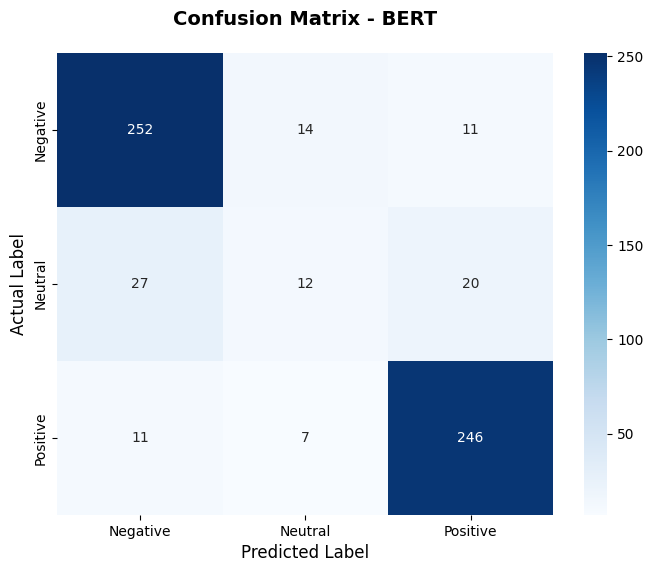


PERFORMANCE EVALUATION: RoBERTa


Accuracy  : 0.8417
F1-Macro  : 0.7080
AUC Score : 0.9065

--- Detailed Classification Report ---
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88       277
     Neutral       0.35      0.32      0.33        59
    Positive       0.90      0.92      0.91       264

    accuracy                           0.84       600
   macro avg       0.71      0.71      0.71       600
weighted avg       0.84      0.84      0.84       600



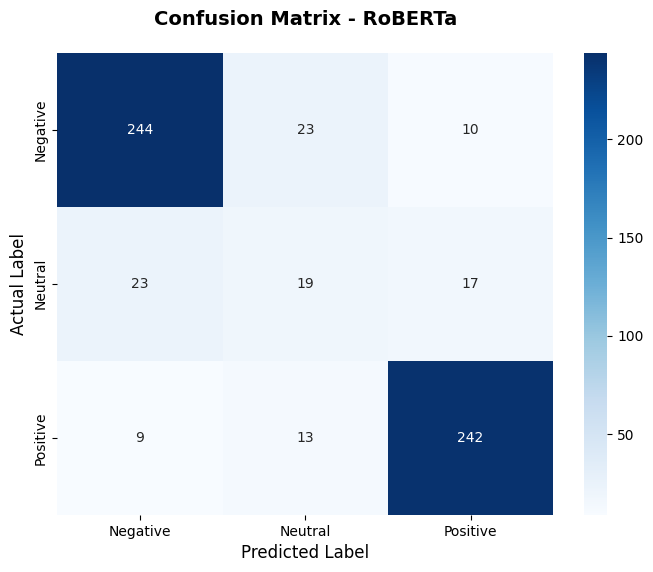


PERFORMANCE EVALUATION: DeBERTa


Accuracy  : 0.8567
F1-Macro  : 0.6808
AUC Score : 0.9238

--- Detailed Classification Report ---
              precision    recall  f1-score   support

    Negative       0.85      0.95      0.90       277
     Neutral       0.36      0.17      0.23        59
    Positive       0.92      0.92      0.92       264

    accuracy                           0.86       600
   macro avg       0.71      0.68      0.68       600
weighted avg       0.83      0.86      0.84       600



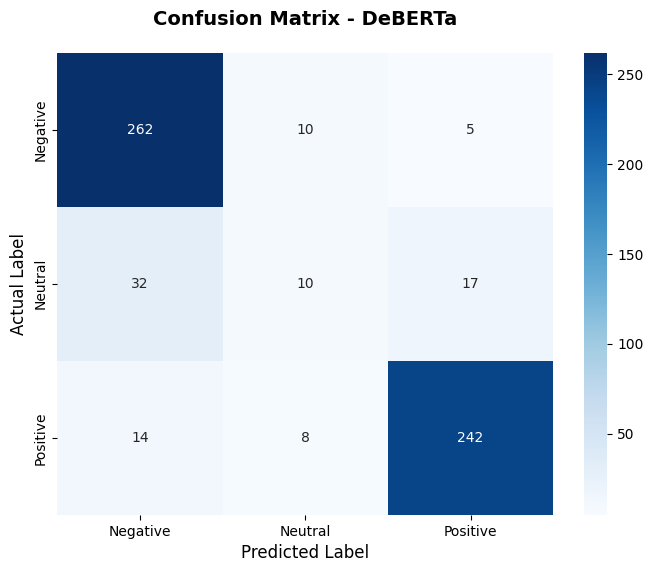

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
from scipy.special import softmax

def evaluate_model_full(model_name, df_results, trainer_obj, tokenizer_obj):
    print(f"\n{'='*60}\nPERFORMANCE EVALUATION: {model_name}\n{'='*60}")

    # 1. Prepare Testing Dataset for Evaluation
    # Ensures the dataset is correctly formatted for the evaluation step
    eval_ds = AirlineReviewDataset(df_results['Hasil_Normalization'], df_results['label'], tokenizer_obj)

    # 2. Extract Ground Truth and Predictions
    y_true = df_results['label'].values
    # Mapping to match English sentiment labels used in previous steps
    mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
    y_pred = df_results[f'Sentiment_{model_name}'].map(mapping).values

    # 3. Extract Logits for AUC Calculation (Probabilities)
    output = trainer_obj.predict(eval_ds)
    probs = softmax(output.predictions, axis=1)

    # 4. Calculate Primary Metrics
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    auc_score = roc_auc_score(y_true, probs, multi_class='ovr')

    print(f"Accuracy  : {acc:.4f}")
    print(f"F1-Macro  : {f1_macro:.4f}")
    print(f"AUC Score : {auc_score:.4f}")
    print("\n--- Detailed Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

    # 5. Visualization: Confusion Matrix Heatmap
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])

    plt.title(f'Confusion Matrix - {model_name}', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('Actual Label', fontsize=12)
    plt.show()

# --- EXECUTE EVALUATION FOR ALL MODELS ---
evaluate_model_full("BERT", df_res_bert, trainer_bert, tokenizer_bert)
evaluate_model_full("RoBERTa", df_res_rob, trainer_rob, tokenizer_rob)
evaluate_model_full("DeBERTa", df_res_deb, trainer_deb, tokenizer_deb)

Generating ROC Curve for BERT...


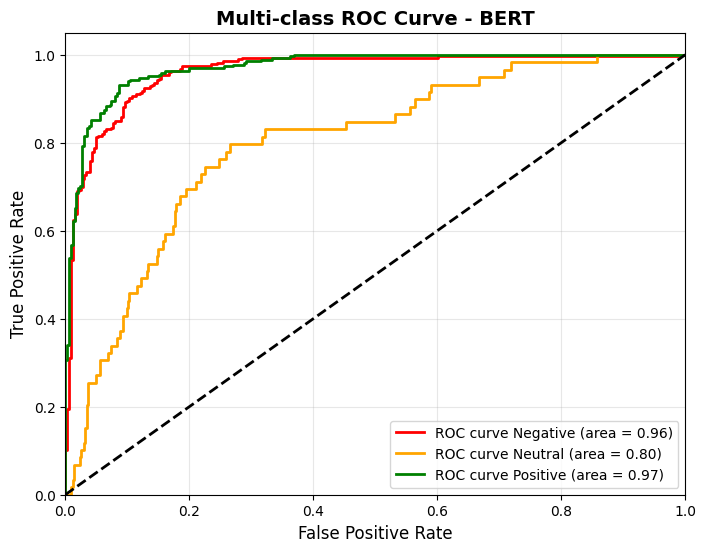

Generating ROC Curve for RoBERTa...


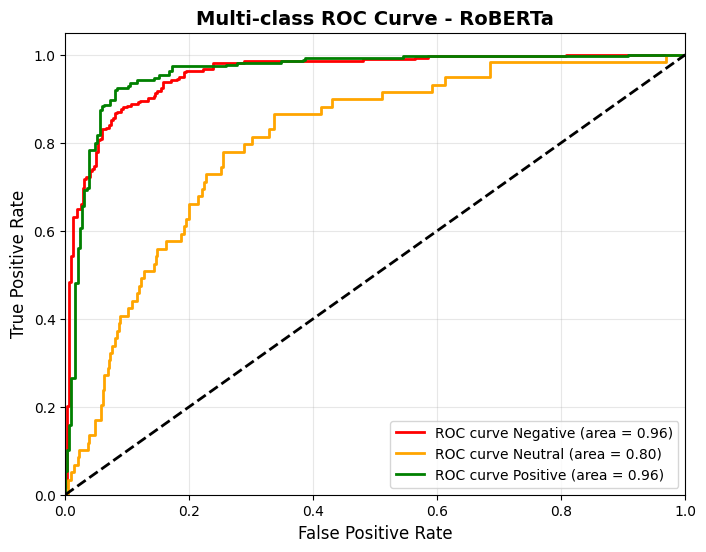

Generating ROC Curve for DeBERTa...


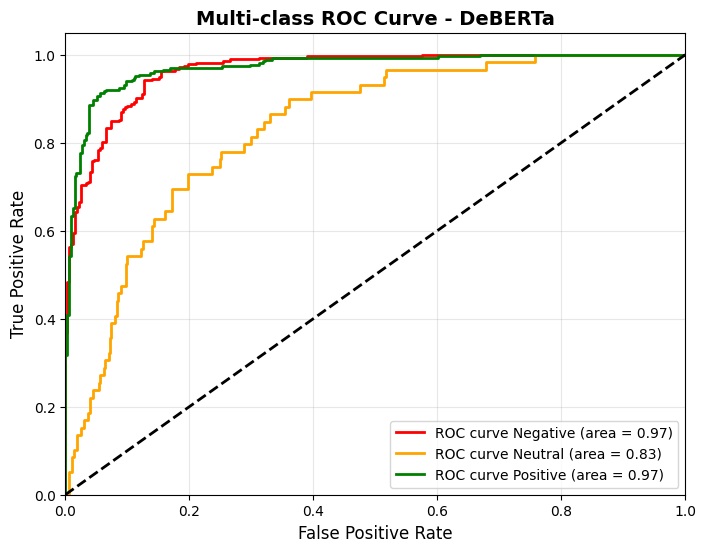

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from scipy.special import softmax

def plot_multiclass_roc(model_name, df_results, trainer_obj, tokenizer_obj):
    print(f"Generating ROC Curve for {model_name}...")

    # 1. Data Preparation & Probability Extraction
    eval_ds = AirlineReviewDataset(df_results['Hasil_Normalization'], df_results['label'], tokenizer_obj)
    y_true = df_results['label'].values
    output = trainer_obj.predict(eval_ds)
    y_score = softmax(output.predictions, axis=1) # Get probabilities for each class

    # 2. Binarize labels for multi-class (0, 1, 2)
    n_classes = 3
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

    # 3. Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    class_names = ['Negative', 'Neutral', 'Positive']
    colors = ['red', 'orange', 'green']

    plt.figure(figsize=(8, 6))

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

        plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
                 label=f'ROC curve {class_names[i]} (area = {roc_auc[i]:.2f})')

    # 4. Plot Diagonal Line (Random Guess)
    plt.plot([0, 1], [0, 1], 'k--', lw=2)

    # 5. Plot Decoration
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'Multi-class ROC Curve - {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# --- EXECUTE AUC VISUALIZATION FOR ALL 3 MODELS ---
plot_multiclass_roc("BERT", df_res_bert, trainer_bert, tokenizer_bert)
plot_multiclass_roc("RoBERTa", df_res_rob, trainer_rob, tokenizer_rob)
plot_multiclass_roc("DeBERTa", df_res_deb, trainer_deb, tokenizer_deb)

# **E. XAI MODULE (EXPLAINABLE AI)**

In [ ]:
from IPython.display import display, HTML
import re
import numpy as np
import torch
import scipy as sp
import pandas as pd
import shap

# 1. Ensure device is defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- PART 1: SAMPLE SELECTION (Target: 20-40 words) ---
df_temp = df_test.copy()
col_to_check = 'Ulasan_Original' if 'Ulasan_Original' in df_test.columns else 'Hasil_Normalization'
df_temp['num_words'] = df_temp[col_to_check].apply(lambda x: len(str(x).split()))

def get_medium_sample(df, label_value, min_w=20, max_w=40):
    filtered_df = df[(df['label'] == label_value) &
                     (df['num_words'] >= min_w) &
                     (df['num_words'] <= max_w)]
    if filtered_df.empty:
        # Fallback if no sample fits the exact range
        filtered_df = df[(df['label'] == label_value) & (df['num_words'] > 15)]
    return filtered_df['Hasil_Normalization'].iloc[0] if not filtered_df.empty else "Data not found"

text_neg_med = get_medium_sample(df_temp, 0)
text_net_med = get_medium_sample(df_temp, 1)
text_pos_med = get_medium_sample(df_temp, 2)

xai_samples_med = np.array([text_neg_med, text_net_med, text_pos_med])

# --- PREVIEW: DATA SAMPLES FOR XAI ANALYSIS ---
print(f"{'='*70}")
print(f"PREVIEW: DATA SAMPLES FOR XAI ANALYSIS (MEDIUM LENGTH)")
print(f"{'='*70}")

preview_data = pd.DataFrame({
    'Sentiment': ['NEGATIVE', 'NEUTRAL', 'POSITIVE'],
    'Sample Review': [text_neg_med, text_net_med, text_pos_med],
    'Word Count': [len(text_neg_med.split()), len(text_net_med.split()), len(text_pos_med.split())]
})

display(HTML(preview_data.to_html(index=False)))
print("\n")

# --- PART 2: SHAP HTML FIX ---
# Fixes a common rendering bug in SHAP where RGB values are wrapped in numpy float types
def fix_shap_html(html):
    def replace_rgb(match):
        nums = re.findall(r'np\.float64\(([\d.e+-]+)\)', match.group(0))
        if len(nums) == 3:
            r, g, b = [float(n) for n in nums]
            return f'rgb({r:.0f}, {g:.0f}, {b:.0f})'
        return match.group(0)

    def replace_rgba(match):
        nums = re.findall(r'np\.float64\(([\d.e+-]+)\)', match.group(0))
        if len(nums) == 4:
            r, g, b, a = [float(n) for n in nums]
            return f'rgba({r:.0f}, {g:.0f}, {b:.0f}, {a:.4f})'
        return match.group(0)

    html = re.sub(
        r'rgba\(np\.float64\([^)]+\),\s*np\.float64\([^)]+\),\s*np\.float64\([^)]+\),\s*np\.float64\([^)]+\)\)',
        replace_rgba, html
    )
    html = re.sub(
        r'rgb\(np\.float64\([^)]+\),\s*np\.float64\([^)]+\),\s*np\.float64\([^)]+\)\)',
        replace_rgb, html
    )
    return html

# --- PART 3: SHAP VISUALIZATION ---
def run_xai_shap_v2(model_obj, tokenizer_obj, model_name, samples):
    print(f"\n{'='*70}\nEXPLAINABLE AI (SHAP) V2: {model_name}\n{'='*70}")

    def predict_probs(texts):
        inputs = tokenizer_obj(texts.tolist(), return_tensors="pt", padding=True,
                               truncation=True, max_length=128).to(device)
        with torch.no_grad():
            logits = model_obj(**inputs).logits
        return sp.special.softmax(logits.cpu().numpy(), axis=1)

    explainer = shap.Explainer(predict_probs, tokenizer_obj)
    shap_values = explainer(samples)

    label_names = {0: "NEGATIVE", 1: "NEUTRAL", 2: "POSITIVE"}

    for i, (sample_idx, class_idx) in enumerate([(0, 0), (1, 1), (2, 2)]):
        label = label_names[class_idx]
        print(f"\n>> [SAMPLE {i+1}] Token Contribution Analysis for {label} Prediction:")

        html_output = shap.plots.text(shap_values[sample_idx, :, class_idx], display=False)
        fixed_html = fix_shap_html(html_output)

        display(HTML(f"""
        <div style="background:white; padding:15px; border-radius:8px;
                    border:1px solid #e0e0e0; margin:8px 0; overflow-x: auto;">
            {fixed_html}
        </div>
        """))

# --- EXECUTION ---
run_xai_shap_v2(model_bert, tokenizer_bert, "BERT", xai_samples_med)
run_xai_shap_v2(model_rob, tokenizer_rob, "RoBERTa", xai_samples_med)
run_xai_shap_v2(model_deb, tokenizer_deb, "DeBERTa", xai_samples_med)

PREVIEW: DATA SAMPLES FOR XAI ANALYSIS (MEDIUM LENGTH)


Sentiment,Sample Review,Word Count
NEGATIVE,very disappointing service from sia plane was dirty departing singapore and staff communication was poor staff were curt to the point of thinly veiled rudeness lots of room for improvement here,31
NEUTRAL,los angeles to singapore this is my rd time for singapore and this is my first time for business class seat when adjusted to be flat bed was not comfortable as i expected food was not okay,37
POSITIVE,good performance on all fronts i would definitely choose to use this airline again the aircraft is well maintained and the staff well trained on hospitality food was plentiful and tasty,31





EXPLAINABLE AI (SHAP) V2: BERT

>> [SAMPLE 1] Token Contribution Analysis for NEGATIVE Prediction:



>> [SAMPLE 2] Token Contribution Analysis for NEUTRAL Prediction:



>> [SAMPLE 3] Token Contribution Analysis for POSITIVE Prediction:


...


>> [SAMPLE 2] Token Contribution Analysis for NEUTRAL Prediction:



>> [SAMPLE 3] Token Contribution Analysis for POSITIVE Prediction:



EXPLAINABLE AI (SHAP) V2: DeBERTa

>> [SAMPLE 1] Token Contribution Analysis for NEGATIVE Prediction:



>> [SAMPLE 2] Token Contribution Analysis for NEUTRAL Prediction:



>> [SAMPLE 3] Token Contribution Analysis for POSITIVE Prediction:
